## Prediction models

In [1]:
import numpy as np
import pandas as pd
df=pd.read_csv('precip.csv')
df.head()

,precip,growth
0,2.176092,25.350882
1,2.280644,17.534213
2,1.703581,28.590446
3,1.061713,21.454899
4,1.718713,14.993775


#### Converting to standard units

In [5]:
def convert_to_su(array):
    mn_subtracted=array-np.mean(array)
    norm_data=mn_subtracted/np.std(array)
    return norm_data

#### Manually calculating Pearson Correlation Coefficient

In [7]:
precip_su = convert_to_su(df['precip'])
growth_su = convert_to_su(df['growth'])
r = np.mean(precip_su*growth_su)
r

0.19418647123114102

#### Plotting the best fit line in standard units

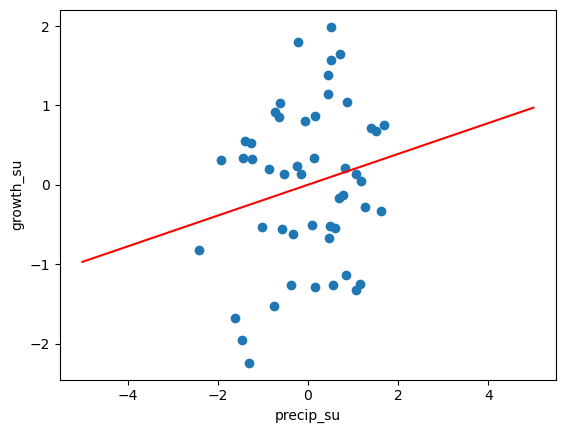

In [10]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots()
ax.scatter(precip_su,growth_su)
ax.set_xlabel('precip_su')
ax.set_ylabel('growth_su')
xvls=np.linspace(-5,5,20)
r=np.mean(precip_su*growth_su)
yvls=r*xvls
ax.plot(xvls,yvls,'r')

#### Quick way to determine Pearson Correlation Coeffecient

In [13]:
corr_matrix=np.corrcoef(df['precip'], df['growth'])
print(corr_matrix)
corr_coeff=corr_matrix[0,1]
print(corr_coeff)

[[1.         0.19418647]
 [0.19418647 1.        ]]
0.19418647123114094


#### Plotting best fit line in original units
slope = r * (sd(y)/sd(x)) <br>
intercept = y - slope(x)

In [18]:
slope = corr_coeff*(np.std(df['growth'])/np.std(df['precip']))
intercept = np.mean(df['growth']) - slope*np.mean(df['precip'])

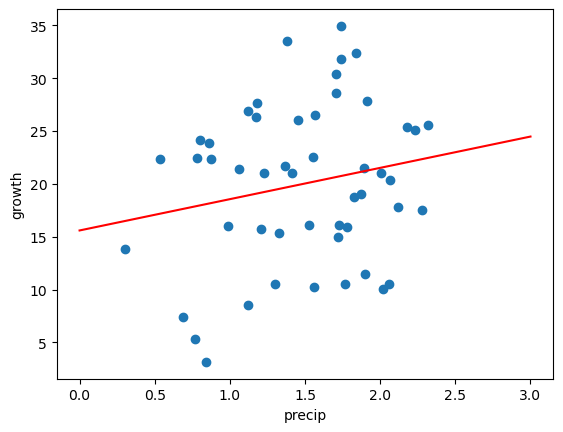

In [20]:
fig,ax=plt.subplots()
ax.scatter(df['precip'],df['growth'])
ax.set_xlabel('precip')
ax.set_ylabel('growth')
xvls=np.linspace(0,3,20)
yvls=slope*xvls+intercept
ax.plot(xvls,yvls,'r')

#### Predicting a value

In [21]:
growth_prediction = slope*3+intercept
growth_prediction

24.481837780469004